In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import json

file_path = "C://Users//Sajindra//Downloads//SENTIMENT_ANALYSIS_FOR_INVESTMENT_DECISIONS_IN_AUSTRALIAN_HOUSING_MARKET_.ipynb"

with open(file_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove widgets metadata if it exists
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=2)

print("Notebook cleaned successfully")

Notebook cleaned successfully


---
## Step 1: Install Dependencies

In [ ]:
# INSTALL GOOGLE CHROME + DRIVER
!apt-get update -qq

# Install dependencies
!apt-get install -y wget unzip -qq

# Install Google Chrome
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb
!apt-get -f install -y -qq


# Install matching ChromeDriver automatically
!pip install selenium webdriver-manager pillow requests --quiet

!pip install gensim nltk pyLDAvis

!pip install transformers torch

print("✅ Setup complete!")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package google-chrome-stable.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack google-chrome-stable_current_amd64.deb ...
Unpacking google-chrome-stable (147.0.7727.55-1) ...
dpkg: dependency problems prevent configuration of google-chrome-stable:
 google-chrome-stable depends on libatk-bridge2.0-0 (>= 2.5.3); however:
  Package libatk-bridge2.0-0 is not installed.
 google-chrome-stable depends on libatk1.0-0 (>= 2.11.90); however:
  Package libatk1.0-0 is not installed.
 google-chrome-stable depends on libatspi2.0-0 (>= 2.9.90); however:
  Package libatspi2.0-0 is not installed.
 google-chrome-stable depends on libvulkan1; however:
  Package libvulkan1 is not installed.
 google-chrome-stable depends on libxcomposite1 (>= 1:0

---
## Step 2: Import Libraries

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
import requests, os, time

from selenium.webdriver.support.ui import WebDriverWait # load all pages
from selenium.webdriver.support import expected_conditions as EC # load all pages

# text processing
import numpy as np # Import NumPy for numerical operations
import pandas as pd # Import Pandas for data manipulation and analysis
import re # remove unwanted texts
from sklearn.feature_extraction.text import (
    CountVectorizer, ENGLISH_STOP_WORDS
)
from collections import Counter # to count words


from sklearn.pipeline import Pipeline

# Gensim LDA
import nltk # Import NLTK for natural language processing tasks
import spacy # Use spaCy for preprocessing (better than basic methods
from nltk.corpus import stopwords     # stop words removal
from gensim import corpora            # Import corpora module to create dictionary and corpus
from gensim.models import LdaModel    # Import LDA model for topic modeling
from gensim.models import CoherenceModel # topic modelling evaluation

# visualization
from wordcloud import WordCloud # visualization of LDA topics
import matplotlib.pyplot as plt
import seaborn as sns
import pyLDAvis.gensim_models as gensimvis  # Import visualization module for Gensim LDA models
import pyLDAvis                        # Import pyLDAvis for interactive topic visualization

# grid serach
import itertools

# Train test split
from sklearn.model_selection import train_test_split

#Embeddings
from sentence_transformers import SentenceTransformer

# Label encoder for Y
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, classification_report

import joblib # save model

# for sentiment analysis
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

#remove unwanted warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("✅ Libraries imported successfully!")

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and sche

✅ Libraries imported successfully!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Get required NLTK datasets (download once)

nltk.download('punkt')       # Download tokenizer models used for splitting text into sentences/words

nltk.download('punkt_tab')   # Download additional tokenizer tables (used internally by punkt in some setups)

nltk.download('stopwords')   # Download list of common stopwords (e.g., "the", "is", "and")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

##Step 3: Configure selenium for Colab for crawling and scraping
We run Chrome in headless mode (no visible browser window), which is required for server/Colab environments.

In [ ]:
# SETUP DRIVER
def get_chrome_driver():
    options = Options()
    options.add_argument('--headless=new')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-gpu')

    # Use Chrome (not chromium)
    options.binary_location = "/usr/bin/google-chrome"

    service = Service(ChromeDriverManager().install())

    driver = webdriver.Chrome(service=service, options=options)
    return driver




1) Scrape from australianpropertyupdate website housing trends page

In [ ]:
# Quick test: can we open a webpage?
driver = get_chrome_driver()
driver.get('https://australianpropertyupdate.com.au/apu/tag/housing-trends')
print(f"✅ WebDriver is working! Page title: {driver.title}")

wait = WebDriverWait(driver, 10)

# Keep clicking "More" until it disappears
while True:

  try:
    more_btn = wait.until(EC.presence_of_element_located(
            (By.XPATH, "//button[contains(., 'More') or contains(., 'Load')]")
      ))
    # Scroll to button (important!)
    driver.execute_script("arguments[0].scrollIntoView();", more_btn)
    time.sleep(2)

    # Click using JS (more reliable)
    driver.execute_script("arguments[0].click();", more_btn)

    # Wait for new content to load
    time.sleep(2)
    print("✅ More button clicked")
  except:
        print("✅ All articles loaded")
        break


In [ ]:
data = []
articles = driver.find_elements(By.CSS_SELECTOR, "div.cst-style.d-flex.col-6.load-post")
for article in articles:
  time.sleep(2)

  try:
        link = article.find_element(By.TAG_NAME, "a").get_attribute("href")
  except:
        link = ""

  try:
        title = article.find_element(By.TAG_NAME, "h2").text
  except:
        title = ""


  data.append({
            "title": title,
            "link": link
        })
print(data)


In [ ]:
df = pd.DataFrame(data)
df.to_csv("australian_property_update_links.csv", index=False)


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/australian_property_update_links.csv")

In [ ]:

# load each article using links
all = []
for i in range(len(df["link"])):

  link = df["link"][i]
  driver = get_chrome_driver()
  driver.get(link)
  time.sleep(2)  # wait for page to load

  try:
    title = driver.find_element(By.CSS_SELECTOR, "span#hs_cos_wrapper_name").text
  except:
    title = ""

  try:
    author = driver.find_element(By.CSS_SELECTOR, "a.author-link").text
  except:
    author = ""

  try:
    spans = driver.find_elements(By.TAG_NAME, "span")
    date = ""
    for s in spans:
      text = s.text.strip()
      if "202" in text:   # simple month check
        date = text
        break
  except:
    date = ""

  try:
    content = driver.find_element(By.CSS_SELECTOR, "div.post-body").text
  except:
    content = ""


  all.append({
        "title": title,
        "link": link,
        "author": author,
        "date": date,
        "content": content
    })
  i = i + 1

print(all)
driver.quit()

In [ ]:
import pandas as pd

df_all = pd.DataFrame(all)
df_all.head(20)

In [ ]:
df_all.to_csv("australian_property_update_all.csv", index=False)

In [ ]:
df_australian_property_update_housingtrends = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/australian_property_update_all.csv")

In [ ]:
df_australian_property_update_housingtrends.shape

(100, 5)

2) Scrape from australianpropertyupdate website Market updates page

In [ ]:
# Quick test: can we open a webpage?
driver = get_chrome_driver()
driver.get('https://australianpropertyupdate.com.au/apu/tag/market-updates')
print(f"✅ WebDriver is working! Page title: {driver.title}")

wait = WebDriverWait(driver, 10)

# Keep clicking "More" until it disappears
while True:

  try:
    more_btn = wait.until(EC.presence_of_element_located(
            (By.XPATH, "//button[contains(., 'More') or contains(., 'Load')]")
      ))
    # Scroll to button (important!)
    driver.execute_script("arguments[0].scrollIntoView();", more_btn)
    time.sleep(2)

    # Click using JS (more reliable)
    driver.execute_script("arguments[0].click();", more_btn)

    # Wait for new content to load
    time.sleep(2)
    print("✅ More button clicked")
  except:
        print("✅ All articles loaded")
        break


In [ ]:
data = []
articles = driver.find_elements(By.CSS_SELECTOR, "div.cst-style.d-flex.col-6.load-post")
for article in articles:
  time.sleep(2)

  try:
        link = article.find_element(By.TAG_NAME, "a").get_attribute("href")
  except:
        link = ""

  try:
        title = article.find_element(By.TAG_NAME, "h2").text
  except:
        title = ""


  data.append({
            "title": title,
            "link": link
        })
print(data)

In [ ]:
df = pd.DataFrame(data)
df.to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/australian_property_update_markettrends_links.csv", index=False)

In [ ]:
# load each article using links
all = []
for i in range(len(df["link"])):

  link = df["link"][i]
  driver = get_chrome_driver()
  driver.get(link)
  time.sleep(2)  # wait for page to load

  try:
    title = driver.find_element(By.CSS_SELECTOR, "span#hs_cos_wrapper_name").text
  except:
    title = ""

  try:
    author = driver.find_element(By.CSS_SELECTOR, "a.author-link").text
  except:
    author = ""

  try:
    spans = driver.find_elements(By.TAG_NAME, "span")
    date = ""
    for s in spans:
      text = s.text.strip()
      if "202" in text:   # simple month check
        date = text
        break
  except:
    date = ""

  try:
    content = driver.find_element(By.CSS_SELECTOR, "div.post-body").text
  except:
    content = ""


  all.append({
        "title": title,
        "link": link,
        "author": author,
        "date": date,
        "content": content
    })
  i = i + 1

print(all)
driver.quit()

In [ ]:
df_all = pd.DataFrame(all)
df_all.head(5)

In [ ]:
df_all.to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/australian_property_update_markettrends_all.csv", index=False)

In [ ]:
df_australian_property_update_markettrends = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/australian_property_update_markettrends_all.csv")

In [ ]:
df_australian_property_update_markettrends.shape

(100, 5)

3) scrape from Michael Yardney's Property update website Propert news page

In [ ]:
# Quick test: can we open a webpage?
driver = get_chrome_driver()
driver.get('https://propertyupdate.com.au/category/news-and-features/')
print(f"✅ WebDriver is working! Page title: {driver.title}")
data = []
i=1
while i < 31: # get the article urls from 30 pages which is from 2026 to 2024 (2 years)
  current_url = 'https://propertyupdate.com.au/category/news-and-features/'+'page/'+str(i)+'/'
  driver.get(current_url)
  print(f"✅ WebDriver is working! Page url: {current_url}")


  articles = driver.find_elements(By.CSS_SELECTOR, "div.articlebox")
  for article in articles:
    try:
        link = article.find_element(By.TAG_NAME, "a").get_attribute("href")
    except:
        link = ""

    # try:
    #     title = article.find_element(By.TAG_NAME, "a").text
    # except:
    #     title = ""

    data.append({
            "title": title,
            "link": link
        })

  i = i+1


print(data)










In [ ]:
df = pd.DataFrame(data)
df.to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/Michael_Yardney_propertynews-links.csv", index=False)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/Michael_Yardney_propertynews-links.csv")

In [ ]:
len(df['link'])

In [ ]:
# load each article using links
all = []
driver = get_chrome_driver()

for i in range(300):
    link = df["link"][i]

    try:
        driver.get(link)
        time.sleep(1)

        try:
            title = driver.find_element(By.CSS_SELECTOR, "h1").text
        except:
            title = ""

        try:
            author = driver.find_element(By.CSS_SELECTOR, "a[href*='/author/']").text
        except:
            author = ""

        try:
            date = driver.find_element(By.CSS_SELECTOR, "time").text
        except:
            date = ""

        try:
            content = driver.find_element(By.CSS_SELECTOR, "div.single-content").text
        except:
            content = ""

        all.append({
            "title": title,
            "link": link,
            "author": author,
            "date": date,
            "content": content
        })

        # ✅ Save after each article (safe)
        pd.DataFrame(all).to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/Michael_Yardney_propertynews-all.csv", index=False, encoding="utf-8")

        print(f"✅ Article {i+1} saved")

    except Exception as e:
        print(f"❌ Error at {link}: {e}")
        continue

driver.quit()  # ✅ close once

In [ ]:
import pandas as pd
df_michal_yardney_propertynews = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/Michael_Yardney_propertynews-all.csv")
df_michal_yardney_propertynews.shape


(300, 5)

## Step 4:  Cleaning & combine articles and Exploratory Data Analysis

In [ ]:
#  Add a column to represent website details
df_australian_property_update_housingtrends['website'] = "Australian_Property_Update/housing-trends"
df_australian_property_update_markettrends['website'] = "Australian_Property_Update/market-trends"
df_michal_yardney_propertynews['website'] = "Michael_Yardney/propertynews"

In [ ]:
#check the dimensions
print("check the dimensions")
print(f"\ndf_australian_property_update_housingtrends shape: {df_australian_property_update_housingtrends.shape}")
print(f"df_australian_property_update_markettrends shape: {df_australian_property_update_markettrends.shape}")
print(f"df_michal_yardney_propertynews shape: {df_michal_yardney_propertynews.shape}")



check the dimensions

df_australian_property_update_housingtrends shape: (100, 6)
df_australian_property_update_markettrends shape: (100, 6)
df_michal_yardney_propertynews shape: (300, 6)


There are 200 and 300 articles from Australian property update website and michael Yardney property update website.  



For Australian property update website articcle content was properly extracted without unwanted content such as their services etc. This was due to the organized html structure of their website. However, in Michael Yardney's website content, there is a description about the services of the company in some of the articles and description about the author at the end of each article . These were removed as they were not relevant for the analysis.

In [ ]:
def cut_after(text):
    return re.split(r"Are you wondering how you should invest in this interesting phase of the property cycle?", text, flags=re.IGNORECASE)[0]

df_michal_yardney_propertynews['content'] = df_michal_yardney_propertynews['content'].apply(cut_after)

In [ ]:
def cut_after1(text):
    return re.split(r"Tip: Need some clarity? Why not start with a complimentary Wealth Discovery Consultation with one of our Property Strategists? Leave us your details here.", text, flags=re.IGNORECASE)[0]

df_michal_yardney_propertynews['content'] = df_michal_yardney_propertynews['content'].apply(cut_after1)

In [ ]:
def cut_after2(text):
    return re.split(r"About Michael Yardney", text, flags=re.IGNORECASE)[0]

df_michal_yardney_propertynews['content'] = df_michal_yardney_propertynews['content'].apply(cut_after2)

In [ ]:
#check the words count
print("\ncheck the word counts")
print(f"df_australian_property_update_housingtrends, average words count of content: {df_australian_property_update_housingtrends['content'].apply(lambda x: len(x.split())).mean()}")
print(f"df_australian_property_update_markettrends, average word count of content: {df_australian_property_update_markettrends['content'].apply(lambda x: len(x.split())).mean()}")
print(f"df_michal_yardney_propertynews, average word count of content: {df_michal_yardney_propertynews['content'].apply(lambda x: len(x.split())).mean()}")


check the word counts
df_australian_property_update_housingtrends, average words count of content: 874.04
df_australian_property_update_markettrends, average word count of content: 954.56
df_michal_yardney_propertynews, average word count of content: 1070.0333333333333


Average length of article content is around 900 in all three lists.

In [ ]:
# combine all three webpages

In [ ]:
df_combined = pd.concat([df_australian_property_update_housingtrends, df_australian_property_update_markettrends, df_michal_yardney_propertynews], ignore_index=True)
df_combined.to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/articles_all.csv", index=False, encoding="utf-8")

In [ ]:
df_combined = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/articles_all.csv", encoding="utf-8")
df_combined.head()

,title,link,author,date,content,website
0,Melbourne and Brisbane to lead property recovery,https://australianpropertyupdate.com.au/apu/me...,Scott Kuru,"January 30, 2025",Australia’s largest bank and biggest home mort...,Australian_Property_Update/housing-trends
1,"$10,000 for tradies won’t ease housing shortag...",https://australianpropertyupdate.com.au/apu/10...,Scott Kuru,"January 28, 2025",Prime Minister Anthony Albanese has unveiled o...,Australian_Property_Update/housing-trends
2,Affordability set to drive Melbourne recovery,https://australianpropertyupdate.com.au/apu/af...,Scott Kuru,"January 21, 2025",ANZ Bank’s economics team has updated its hous...,Australian_Property_Update/housing-trends
3,Ten top locations for property investing in 2025,https://australianpropertyupdate.com.au/apu/te...,Scott Kuru,Ten top locations for property investing in 2025,"Recently, the Australian Financial Review news...",Australian_Property_Update/housing-trends
4,Sydney and Melbourne's exodus by younger gener...,https://australianpropertyupdate.com.au/apu/sy...,Scott Kuru,"October 16, 2024","Australia’s two largest capital cities, Sydney...",Australian_Property_Update/housing-trends


In [ ]:
df_combined.shape

(500, 6)

In [ ]:
type(df_combined['title'])

pandas.core.series.Series

In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    500 non-null    object
 1   link     500 non-null    object
 2   author   500 non-null    object
 3   date     500 non-null    object
 4   content  500 non-null    object
 5   website  500 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [ ]:
# check for missing values
df_combined.isna().sum() # it doesn't show null values

,0
title,0
link,0
author,0
date,0
content,0
website,0


In [ ]:
# check for duplicates
df_combined.duplicated().sum() # no duplicates

np.int64(0)

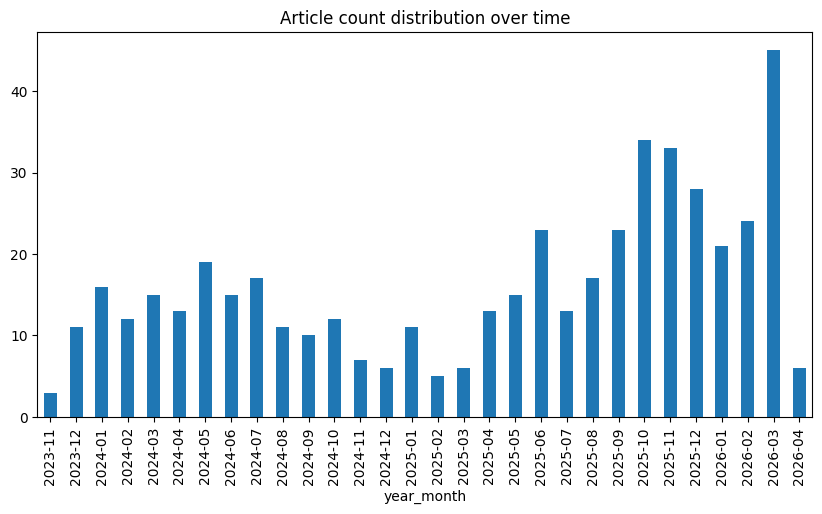

In [ ]:
# convert date column to datetime and plot histogram
df_combined['date'] = pd.to_datetime(df_combined['date'], errors='coerce')
df_combined['year_month'] = df_combined['date'].dt.to_period('M')
df_combined['year_month'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title("Article count distribution over time")
plt.show() # articlesa are distributed each month between Nov 2023 and April 2026. Article count has increased during October 2025 to March 2026.

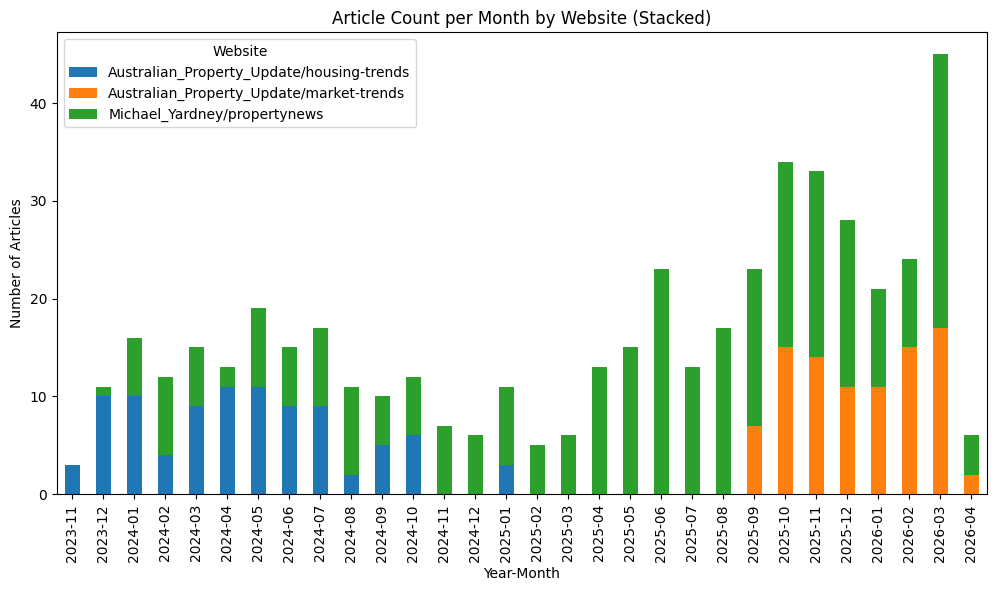

In [ ]:


# Group and pivot
df_plot = df_combined.groupby(['year_month', 'website']).size().unstack(fill_value=0)

# Optional: sort by time
df_plot = df_plot.sort_index()

# Plot stacked bar chart
df_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.xticks(rotation=90)
plt.title("Article Count per Month by Website (Stacked)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Articles")
plt.legend(title="Website")
plt.show()

In [ ]:
df_combined['date'].unique() # there are values missing "NaT"

<DatetimeArray>
['2025-01-30 00:00:00', '2025-01-28 00:00:00', '2025-01-21 00:00:00',
                 'NaT', '2024-10-16 00:00:00', '2024-10-15 00:00:00',
 '2024-10-14 00:00:00', '2024-10-11 00:00:00', '2024-10-07 00:00:00',
 '2024-10-04 00:00:00',
 ...
 '2024-03-19 00:00:00', '2024-03-07 00:00:00', '2024-02-26 00:00:00',
 '2024-02-25 00:00:00', '2024-02-03 00:00:00', '2024-02-01 00:00:00',
 '2024-01-19 00:00:00', '2024-01-13 00:00:00', '2024-01-12 00:00:00',
 '2023-12-20 00:00:00']
Length: 372, dtype: datetime64[ns]

In [ ]:
df_combined = df_combined.dropna()
print(f"Size of the dataframe after dropping NA values: {df_combined.shape}") # 16 values dropped

Size of the dataframe after dropping NA values: (484, 7)


Number of authors: 20


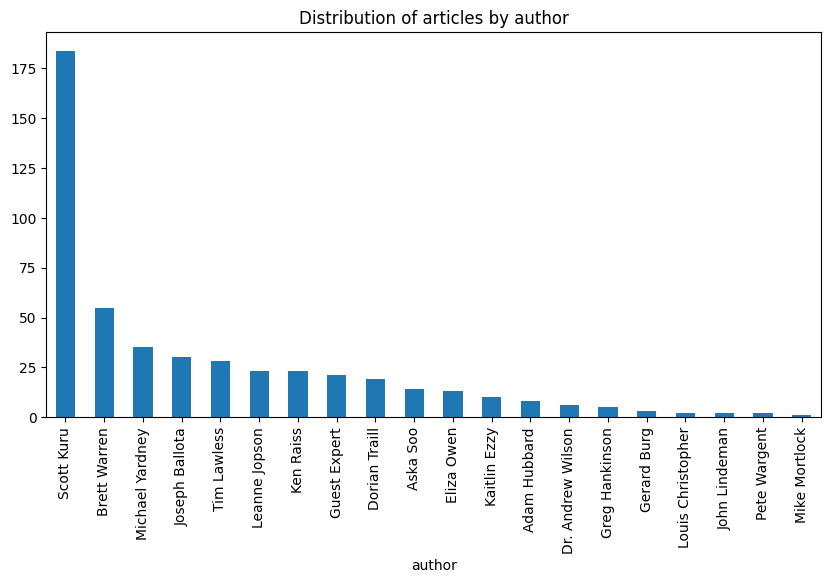

In [ ]:
# distribution of articles by author
print(f"Number of authors: {len(df_combined['author'].unique())}") # author count

df_combined['author'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Distribution of articles by author")
plt.show()
# there are 20 unique authors. Scott Kuru has published highest number of posts which is 184 out of 484.

In [ ]:
# check word count distribution
df_combined['word_count'] = df_combined['content'].apply(lambda x: len(str(x).split()))


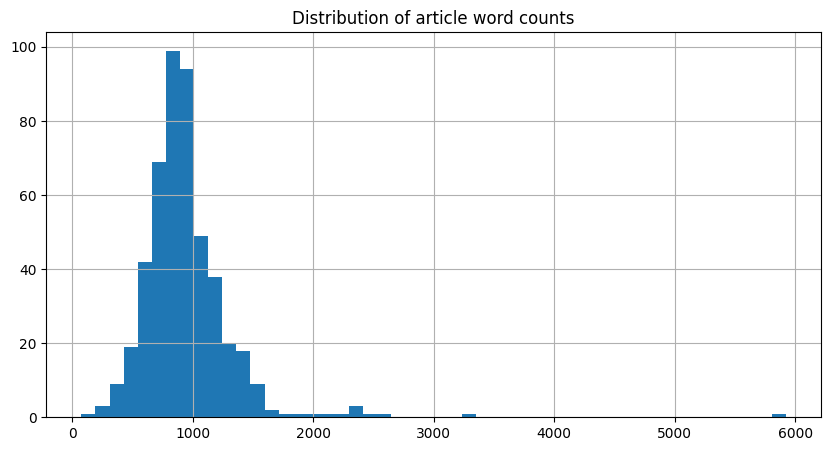

In [ ]:
# word count distribution
df_combined['word_count'].hist(bins=50, figsize=(10,5))
plt.title("Distribution of article word counts")
plt.show() # There are considerable amount of articles with more than 1500 words

In [ ]:
# Summary stats
df_combined.describe() #Min word count and max word count are 77 and 5922 while mean is 945.

,date,word_count
count,484,484.000000
mean,2025-04-22 05:06:26.776859392,945.857438
min,2023-11-27 00:00:00,77.000000
25%,2024-08-01 12:00:00,741.000000
50%,2025-07-01 00:00:00,895.000000
75%,2025-12-01 06:00:00,1076.250000
max,2026-04-02 00:00:00,5922.000000
std,NaN,405.389553


In [ ]:
df_combined[df_combined['word_count']<300] # there are 4 articles less than 300 words. One articles has only 77 words which will be removed as it can be noisy and distort topics in topic modelling and sementic analysis.
# Since most of the articles are having more than 300 words is good for topic quality and sementic analysis.

,title,link,author,date,content,website,year_month,word_count
336,Resilient rents and low vacancies keep east co...,https://propertyupdate.com.au/resilient-rents-...,Brett Warren,2025-08-04,"As we move through the cooler months, Australi...",Michael_Yardney/propertynews,2025-08,285
412,RBA RATE CUT: Decoding The Impact Of The RBA R...,https://propertyupdate.com.au/rba-rate-cut-dec...,Michael Yardney,2025-02-19,Now that the RBA has cut the cash rate for the...,Michael_Yardney/propertynews,2025-02,77
438,Does this mean no interest rate cut this year?,https://propertyupdate.com.au/does-this-mean-n...,Michael Yardney,2024-10-18,"Key takeaways\nMore than 64,000 people found j...",Michael_Yardney/propertynews,2024-10,280
484,Housing construction slows; Victoria to fall f...,https://propertyupdate.com.au/housing-construc...,Pete Wargent,2024-03-01,With another building firm going into administ...,Michael_Yardney/propertynews,2024-03,290


In [ ]:
df_combined[df_combined['word_count'] > 2000].count() # check articles with greater than 2000 words. There are only 9 articles with more tha 2000 words. This has no significant impact on LDA topic modelling.
# Therefore, enitre articles will be used for topic modelling and topic will be assigned for each article.

,0
title,9
link,9
author,9
date,9
content,9
website,9
year_month,9
word_count,9


In [ ]:
df_final = df_combined[df_combined['word_count'] > 100] # remove articles with less than 100 as it has no meaning
df_final.shape

(483, 8)

In [ ]:
df_final.head(10)

,title,link,author,date,content,website,year_month,word_count
0,Melbourne and Brisbane to lead property recovery,https://australianpropertyupdate.com.au/apu/me...,Scott Kuru,2025-01-30,Australia’s largest bank and biggest home mort...,Australian_Property_Update/housing-trends,2025-01,727
1,"$10,000 for tradies won’t ease housing shortag...",https://australianpropertyupdate.com.au/apu/10...,Scott Kuru,2025-01-28,Prime Minister Anthony Albanese has unveiled o...,Australian_Property_Update/housing-trends,2025-01,1005
2,Affordability set to drive Melbourne recovery,https://australianpropertyupdate.com.au/apu/af...,Scott Kuru,2025-01-21,ANZ Bank’s economics team has updated its hous...,Australian_Property_Update/housing-trends,2025-01,689
4,Sydney and Melbourne's exodus by younger gener...,https://australianpropertyupdate.com.au/apu/sy...,Scott Kuru,2024-10-16,"Australia’s two largest capital cities, Sydney...",Australian_Property_Update/housing-trends,2024-10,893
5,Rental crisis looms as investors flee Victoria...,https://australianpropertyupdate.com.au/apu/re...,Scott Kuru,2024-10-15,If you read a lot of property stories in the m...,Australian_Property_Update/housing-trends,2024-10,1007
6,Visa extensions for international students put...,https://australianpropertyupdate.com.au/apu/vi...,Scott Kuru,2024-10-14,I recently wrote about the key population stat...,Australian_Property_Update/housing-trends,2024-10,980
7,Strong Spring buyer demand driven by investors,https://australianpropertyupdate.com.au/apu/st...,Scott Kuru,2024-10-11,CoreLogic’s latest housing chart pack clearly ...,Australian_Property_Update/housing-trends,2024-10,679
8,Interest rate cuts could boost Sydney property...,https://australianpropertyupdate.com.au/apu/in...,Scott Kuru,2024-10-07,Recent data has shown that Australian home pri...,Australian_Property_Update/housing-trends,2024-10,979
9,Why Sydney home prices aren’t falling anytime ...,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,2024-10-04,"If you scan newspaper headlines, you might thi...",Australian_Property_Update/housing-trends,2024-10,1007
10,No mortgage pain relief - RBA keeps rates on h...,https://australianpropertyupdate.com.au/apu/rb...,Scott Kuru,2024-09-24,The board of the Reserve Bank of Australia (RB...,Australian_Property_Update/housing-trends,2024-09,897


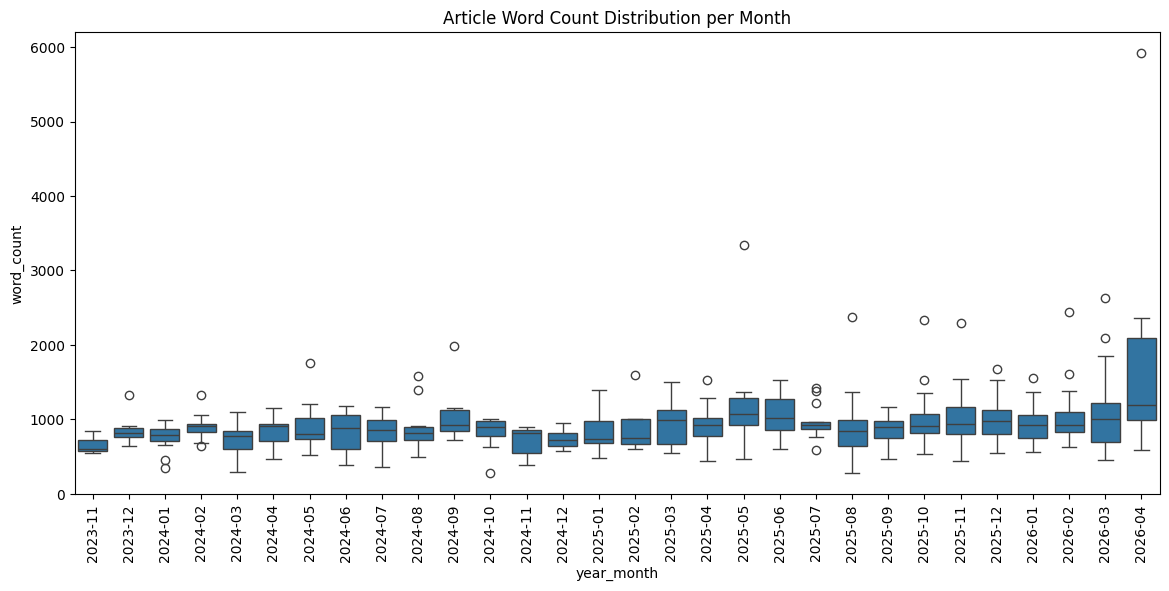

In [ ]:
plt.figure(figsize=(14,6))
df_final = df_final.sort_values('year_month')
sns.boxplot(data=df_final, x='year_month', y='word_count')
plt.xticks(rotation=90)
plt.title("Article Word Count Distribution per Month")
plt.show() # we can see the word count distribution varies over the time. There are few extreme counts visible in some months. However, this will have no significant impact on topic modelling using LDA.

## Step 5: Topic modelling - Latent Dirichlet Allocation (LDA)
since we need to identify content-driven topics, only the article content will be considered and other data like title, author will not be considered. This will avoid bias from metadata such as author names and titles.

### 5.1 Preprocessing for LDA

In [ ]:
# Tokenization and stopword removal

#STOP_WORDS = ENGLISH_STOP_WORDS   # built into sklearn, no download needed
STOP_WORDS = set(stopwords.words('english'))


# STOP_WORDS = STOP_WORDS.union(custom_stopwords)

def simple_lemmatize(word):
    """Rule-based suffix stripper — replaces NLTK WordNetLemmatizer."""
    for suffix in ("ies","es","ing","ed","er","ly","tion","ness","s"):
        if word.endswith(suffix) and len(word) - len(suffix) > 2:
            return word[:-len(suffix)]
    return word

def preprocess(text):
    """
    1. Lowercase
    2. Remove HTML tags
    3. Remove special chars / digits
    4. Tokenise
    5. Remove stopwords
    6. Lemmatise
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)          # 2. strip HTML
    text = re.sub(r"[^a-z\s]", " ", text)          # 3. letters only
    tokens = text.split()                           # 4. tokenise
    tokens = [t for t in tokens
              if t not in STOP_WORDS and len(t) > 2]  # 5. stopwords
    tokens = [simple_lemmatize(t) for t in tokens] # 6. lemmatise
    return tokens
    #return " ".join(tokens)

df_final['processed_content'] = [preprocess(d) for d in df_final['content']]



In [ ]:
df_final.head() # this shows the preprocessed text

,title,link,author,date,content,website,year_month,word_count,processed_content
97,Imported Builders: The Solution to Australia's...,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,2023-11-29,People often ask me why I am so optimistic abo...,Australian_Property_Update/housing-trends,2023-11,841,"[people, often, ask, optimistic, outlook, cont..."
98,Why Migration is Fuelling Greater House Price ...,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,2023-11-28,Immigration has always been at the heart of ou...,Australian_Property_Update/housing-trends,2023-11,545,"[immigra, alway, heart, nation, growth, need, ..."
99,Regional versus Capital: Which is the Best Inv...,https://australianpropertyupdate.com.au/apu/re...,Scott Kuru,2023-11-27,Some people insist you should only invest in c...,Australian_Property_Update/housing-trends,2023-11,606,"[people, insist, invest, capital, cit, other, ..."
92,Rosehill Racecourse: A Model for Future Urban ...,https://australianpropertyupdate.com.au/apu/ro...,Scott Kuru,2023-12-10,The Golden Slipper - the world's richest race ...,Australian_Property_Update/housing-trends,2023-12,847,"[golden, slipp, world, richest, race, two, yea..."
95,House Prices Stabilize as Housing Market Cools...,https://australianpropertyupdate.com.au/apu/ho...,Scott Kuru,2023-12-05,New figures show some of the heat has come out...,Australian_Property_Update/housing-trends,2023-12,783,"[new, figur, show, heat, come, hous, market, h..."


In [ ]:
# Prepare the dictionary and corpus for LDA (topic modeling)

# Create a dictionary representation of the documents
# This maps each unique word to a unique ID
dictionary = corpora.Dictionary(df_final['processed_content'])
print(f"Number of unique tokens: {len(dictionary)}")

# Filter extremes (VERY IMPORTANT)
dictionary.filter_extremes(no_below=5, no_above=0.5) # remove words that appear in less than 4 articles and also appear in more than 50% of the articles
print(f"Number of unique tokens after filtering: {len(dictionary)}")

# Step 3: Create a corpus: list of bag-of-words (BoW) vectors
# Each document is converted into a list of (word_id, word_count)
corpus = [dictionary.doc2bow(doc) for doc in df_final['processed_content']]

Number of unique tokens: 8385
Number of unique tokens after filtering: 3166


In [ ]:
print(corpus[0]) # corpus will show the word ID and the frequency of that word for each document. Print the first document corpus
print([dictionary[id] for id, freq in corpus[0]])

[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1), (6, 2), (7, 1), (8, 1), (9, 1), (10, 1), (11, 2), (12, 2), (13, 1), (14, 2), (15, 2), (16, 2), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 2), (23, 1), (24, 2), (25, 9), (26, 3), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 2), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 2), (40, 5), (41, 3), (42, 1), (43, 2), (44, 1), (45, 1), (46, 2), (47, 2), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 3), (63, 1), (64, 2), (65, 1), (66, 2), (67, 1), (68, 1), (69, 1), (70, 2), (71, 1), (72, 3), (73, 2), (74, 1), (75, 1), (76, 6), (77, 2), (78, 1), (79, 3), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 1), (90, 1), (91, 2), (92, 1), (93, 1), (94, 8), (95, 1), (96, 1), (97, 1), (98, 2), (99, 1), (100, 1), (101, 1), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 2), (108, 3), (109, 1), (110, 1),

### 5.2 Train LDA model

In [ ]:
# Initialize the LDA (Latent Dirichlet Allocation) model
# LDA finds hidden topics in a collection of documents

# Parameter grid
param_grid = {
    "num_topics": [3,4,5,6],
    "alpha": ["symmetric", "asymmetric"],
    "eta": ["symmetric", "auto"],
    "passes": [10, 20, 30]
}

grid = list(itertools.product(
    param_grid["num_topics"],
    param_grid["alpha"],
    param_grid["eta"],
    param_grid["passes"]
))
results = []

for num_topics, alpha, eta, passes in grid:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        passes=passes,
        random_state=42
    )

    coherence_model = CoherenceModel(
        model=lda,
        texts=df_final['processed_content'],
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_score = coherence_model.get_coherence() # # Compute coherence (Gensim). Measures how interpretable your topics are. Higher = better topics
    results.append({
        "num_topics": num_topics,
        "alpha": alpha,
        "eta": eta,
        "passes": passes,
        "coherence": coherence_score
    })



In [ ]:
results = pd.DataFrame(results)
print(results)

    num_topics       alpha        eta  passes  coherence
0            3   symmetric  symmetric      10   0.463448
1            3   symmetric  symmetric      20   0.470450
2            3   symmetric  symmetric      30   0.470450
3            3   symmetric       auto      10   0.463448
4            3   symmetric       auto      20   0.470450
5            3   symmetric       auto      30   0.470450
6            3  asymmetric  symmetric      10   0.463448
7            3  asymmetric  symmetric      20   0.470450
8            3  asymmetric  symmetric      30   0.470450
9            3  asymmetric       auto      10   0.463448
10           3  asymmetric       auto      20   0.470450
11           3  asymmetric       auto      30   0.470450
12           4   symmetric  symmetric      10   0.474086
13           4   symmetric  symmetric      20   0.475325
14           4   symmetric  symmetric      30   0.478546
15           4   symmetric       auto      10   0.474086
16           4   symmetric     

In [ ]:
# identify best parameters
print("Best parameters")
best = results.loc[results['coherence'].idxmax()]
print(best)
results_4 = results[results['num_topics'] == 4]
print("\nBest parameters with 4 topics")
best_4 = results_4.loc[results_4['coherence'].idxmax()]
print(best_4)
# eventhough 6 topics gives the best coherence of 0.5 due to difficulties in interpreting, 5 topics were used (coherence is 0.49 which is acceptable). However, then two topics were mostly overlapping
#according to the pyLDAvis visualization. Therefore, decided to use only 4 topics.

Best parameters
num_topics            6
alpha         symmetric
eta           symmetric
passes               30
coherence      0.502425
Name: 38, dtype: object

Best parameters with 4 topics
num_topics            4
alpha         symmetric
eta           symmetric
passes               30
coherence      0.478546
Name: 14, dtype: object


In [ ]:
# Train LDA with 4 topics
lda_best = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    alpha='symmetric',
    eta='symmetric',
    passes=30,
    random_state=42
)



In [ ]:
# Check the topics and top words
topic_words = {}

for topic_id in range(lda_best.num_topics):
    words = lda_best.show_topic(topic_id, topn=10)
    topic_words[topic_id] = ", ".join([word for word, prob in words])

    print(f"Topic {topic_id}: {topic_words[topic_id]}")



Topic 0: loan, build, billion, lend, construc, own, per, cent, state, approval
Topic 1: infla, bank, rba, cut, expect, cash, household, economy, mortgage, next
Topic 2: government, rental, tax, need, people, wealth, investment, area, income, build
Topic 3: median, unit, rental, valu, city, perth, house, value, cit, regional


Topic 0: Construction and finance. This focus on property development, and lending

Topic 1: Economic conditions. This focus on macro economic signals such as inflation, central bank (RBA) decisions and morgage rates

Topic 2: Government policy and investment. This focus on taxes, policy, rental, income etc.

Topic 3: Property prices. This focus on market considitions such as median prices, rentals, city Vs regional areas etc.


Therefore, the topics are distinct, coherent within each topic and cover full housing eco system.

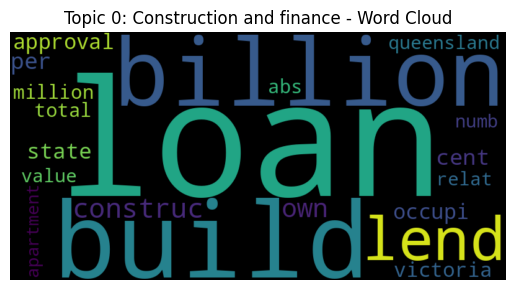

In [ ]:

# get words from topic 0
topic0_words = dict(lda_best.show_topic(0, topn=20))
wordcloud0 = WordCloud(width=800, height=400).generate_from_frequencies(topic0_words)

plt.imshow(wordcloud0, interpolation='bilinear')
plt.axis("off")
plt.title("Topic 0: Construction and finance - Word Cloud")
plt.show()

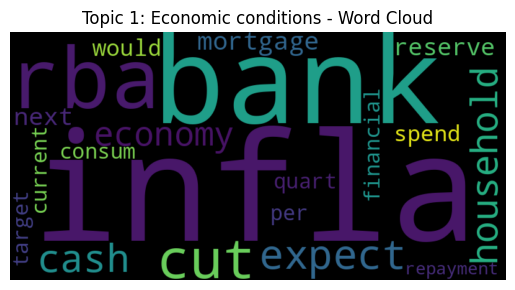

In [ ]:
# get words from topic 1
topic1_words = dict(lda_best.show_topic(1, topn=20))
wordcloud1 = WordCloud(width=800, height=400).generate_from_frequencies(topic1_words)

plt.imshow(wordcloud1, interpolation='bilinear')
plt.axis("off")
plt.title("Topic 1: Economic conditions - Word Cloud")
plt.show()

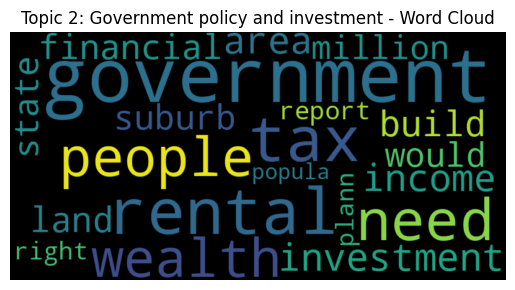

In [ ]:
# get words from topic 2
topic2_words = dict(lda_best.show_topic(2, topn=20))
wordcloud2 = WordCloud(width=800, height=400).generate_from_frequencies(topic2_words)

plt.imshow(wordcloud2, interpolation='bilinear')
plt.axis("off")
plt.title("Topic 2: Government policy and investment - Word Cloud")
plt.show()

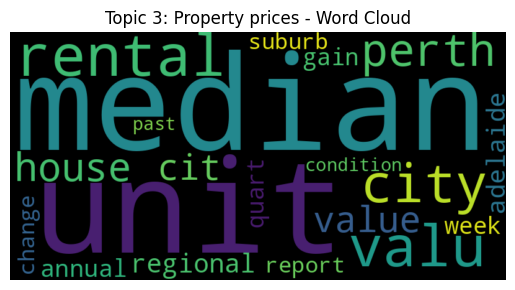

In [ ]:
# get words from topic 2
topic3_words = dict(lda_best.show_topic(3, topn=20))
wordcloud3 = WordCloud(width=800, height=400).generate_from_frequencies(topic3_words)

plt.imshow(wordcloud3, interpolation='bilinear')
plt.axis("off")
plt.title("Topic 3: Property prices - Word Cloud")
plt.show()

In [ ]:
topic_name = {0: "Construction and finance",
              1: "Economic conditions",
              2: "Government policy and investment",
              3: "Property prices"

              }

In [ ]:
vis = gensimvis.prepare(lda_best, corpus, dictionary)
pyLDAvis.save_html(vis, "lda_visualization.html")
#“Note that topic numbering in PyLDAvis differs from Gensim due to reordering based on topic prevalence. Therefore, topics were interpreted by comparing their top words rather than relying on numeric labels.”
# Topic mapping: Gensim 0 = PyLDAvis 4, Gensim 1 = PyLDAvis 3, Gensim 2 = PyLDAvis 1, Gensim 3 = PyLDAvis 2
#“The 4-topic model was selected as it produced well-separated and distinct topics in the intertopic distance map. Although the coherence score was slightly lower than the 5-topic model, the improved interpretability and reduced overlap justified the selection.”

In [ ]:
pyLDAvis.display(vis)

In [ ]:
#Topic distribution per document
doc_topics = [lda_best.get_document_topics(doc) for doc in corpus] # this shows the percentage distribution of topics in first 5 document
doc_topics[:3]


[[(0, np.float32(0.56736654)),
  (1, np.float32(0.07985249)),
  (2, np.float32(0.35190788))],
 [(0, np.float32(0.36779866)), (2, np.float32(0.62931865))],
 [(2, np.float32(0.50660837)), (3, np.float32(0.49097818))]]

In [ ]:
dominant_topics_with_prob = []

for doc in corpus:
    doc_topics = lda_best.get_document_topics(doc)
    if doc_topics:
        dominant_topic = max(doc_topics, key=lambda x: x[1])
    else:
        dominant_topic = ("N", 0.0)
    dominant_topics_with_prob.append(dominant_topic)

dominant_topics_with_prob = pd.DataFrame(dominant_topics_with_prob, columns=['Dominant_Topic', 'Probability'])

dominant_topics_with_prob.head(5)

,Dominant_Topic,Probability
0,0,0.567368
1,2,0.629316
2,2,0.506609
3,2,0.900699
4,3,0.926588


In [ ]:
dominant_topics_with_prob['Dominant_Topic'].value_counts()

,count
Dominant_Topic,
2,170
3,165
1,87
0,61


In [ ]:
# combine with topic name
df_topics = pd.DataFrame(
    dominant_topics_with_prob,
    columns=['Dominant_Topic', 'Probability']
)
#df_topics = dominant_topics_with_prob['Dominant_Topic']

# map the top words to topic
df_topics['Top_Words'] = df_topics['Dominant_Topic'].map(topic_words)
#df_topics.head()

#map the topic name to topic
df_topics['Topic_Name'] = df_topics['Dominant_Topic'].map(topic_name)
#df_topics.head()

# combine dominant_topics dataframe with top words
topic_final = pd.concat([df_final.reset_index(drop=True), df_topics.reset_index(drop=True)], axis=1)

topic_final.head(5)


,title,link,author,date,content,website,year_month,word_count,processed_content,Dominant_Topic,Probability,Top_Words,Topic_Name
0,Imported Builders: The Solution to Australia's...,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,2023-11-29,People often ask me why I am so optimistic abo...,Australian_Property_Update/housing-trends,2023-11,841,"[people, often, ask, optimistic, outlook, cont...",0,0.567368,"loan, build, billion, lend, construc, own, per...",Construction and finance
1,Why Migration is Fuelling Greater House Price ...,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,2023-11-28,Immigration has always been at the heart of ou...,Australian_Property_Update/housing-trends,2023-11,545,"[immigra, alway, heart, nation, growth, need, ...",2,0.629316,"government, rental, tax, need, people, wealth,...",Government policy and investment
2,Regional versus Capital: Which is the Best Inv...,https://australianpropertyupdate.com.au/apu/re...,Scott Kuru,2023-11-27,Some people insist you should only invest in c...,Australian_Property_Update/housing-trends,2023-11,606,"[people, insist, invest, capital, cit, other, ...",2,0.506609,"government, rental, tax, need, people, wealth,...",Government policy and investment
3,Rosehill Racecourse: A Model for Future Urban ...,https://australianpropertyupdate.com.au/apu/ro...,Scott Kuru,2023-12-10,The Golden Slipper - the world's richest race ...,Australian_Property_Update/housing-trends,2023-12,847,"[golden, slipp, world, richest, race, two, yea...",2,0.900699,"government, rental, tax, need, people, wealth,...",Government policy and investment
4,House Prices Stabilize as Housing Market Cools...,https://australianpropertyupdate.com.au/apu/ho...,Scott Kuru,2023-12-05,New figures show some of the heat has come out...,Australian_Property_Update/housing-trends,2023-12,783,"[new, figur, show, heat, come, hous, market, h...",3,0.926588,"median, unit, rental, valu, city, perth, house...",Property prices


In [ ]:
topic_final.to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/topic_final.csv", index=False)

In [ ]:
topic_final = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/topic_final.csv")

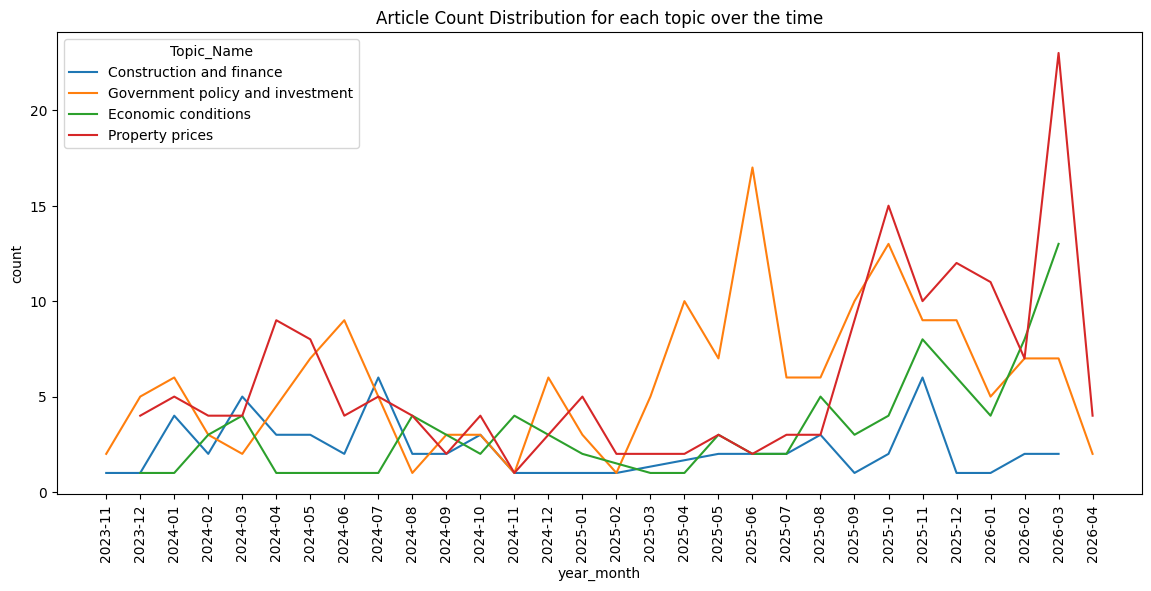

In [ ]:
# check the topic wise distribution of articles over the time
plt.figure(figsize=(14,6))
topic_final_group = topic_final.groupby(['year_month', 'Topic_Name']).size().reset_index(name='count')
sns.lineplot(data=topic_final_group, x='year_month', y='count', hue='Topic_Name')
plt.xticks(rotation=90)
plt.title("Article Count Distribution for each topic over the time")
plt.show() # we can see the word count distribution varies over the time. There are few extreme counts visible in some months. However, this will have no significant impact on topic modelling using LDA.
# most of the articles are related to Property prices and Government policy and investment topics. Property prices articles have significantly increased in March 2026.

# Train a MLP(Multilayer Perceptron) to predict the topic of new articles
This topic modelling result will be used to train a MLP to classify the new unseen articles from the web. For this task, instead of using traditional TF-IDF vectorization, embeddings will be used. Because embeddings can capture the sementic meaning (ex:“housing prices” and “property values” are related). It works well for noisy and short texts and also we can fine-tune or extend the classifier without retraining from scratch in the future.

Then the content needs to be combined with other important fields for classification model.

In [ ]:
# Combine all fields to one text. Give more weights to important fields
topic_final['combined_text'] = (
    (topic_final['title'] + ' ')*2 +
    (topic_final['author'] + ' ')*1 +
    topic_final['content']
)

# assign article ID to track the article
topic_final['article_id']  = topic_final.index

### Chunking articles to avoid very long article
Very long articles can cause problems in classification models. Therefore, instead of removing long articles, they are split into chunks before training the model. By considering the maximum token size of all-MiniLM-L6-v2 embedding, which is 256, articles were chunked using chunk size 200 and minimum chunk size is 80(Appendix 14). If there are remaining chunks less than 80 words, they will be merged with the previous chunk to avoid very small chunks.

Scraped data → Cleaning -> Combine documents -> Combine fields to one text field -> Chunk text → Light Preprocess → word embeddings → Train MLP

In [ ]:
# define chunk function
def smart_chunk(text, chunk_size=200, min_chunk=80):
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = words[i:i+chunk_size]
        chunks.append(chunk)

    # Handle small last chunk
    if len(chunks) > 1 and len(chunks[-1]) < min_chunk:
        chunks[-2].extend(chunks[-1])
        chunks.pop()

    # Convert back to text
    return [" ".join(chunk) for chunk in chunks]

In [ ]:
# Expand DataFrame into chunks
chunk_rows = []

for idx, row in topic_final.iterrows():
  chunks = smart_chunk(row['combined_text'])

  for chunk in chunks:
        chunk_rows.append({
            "title": row['title'],
            "article_id": row['article_id'], # important for grouping later
            "link": row['link'],
            "author": row['author'],
            "website": row['website'],
            "date": row['date'],
            "year_month": row['year_month'],
            "Topic_Name": row['Topic_Name'],
            "combined_text": row['combined_text'],
            "chunk": chunk,
            "word_count": len(chunk.split())
        })


df_chunks = pd.DataFrame(chunk_rows)

In [ ]:
df_chunks.head(10) # content of article is splitted into chunks

,title,article_id,link,author,website,date,year_month,Topic_Name,combined_text,chunk,word_count
0,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,Imported Builders: The Solution to Australia's...,200
1,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,leave the country for good. But my tip is this...,200
2,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,solution. It wants the Federal government to o...,200
3,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,down.” Melbourne and Brisbane to lead property...,261
4,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,Why Migration is Fuelling Greater House Price ...,200
5,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,minus how many left) accounts for the lion’s s...,200
6,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,that far exceeds our ability to house people. ...,169
7,Regional versus Capital: Which is the Best Inv...,2,https://australianpropertyupdate.com.au/apu/re...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-27,2023-11,Government policy and investment,Regional versus Capital: Which is the Best Inv...,Regional versus Capital: Which is the Best Inv...,200
8,Regional versus Capital: Which is the Best Inv...,2,https://australianpropertyupdate.com.au/apu/re...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-27,2023-11,Government policy and investment,Regional versus Capital: Which is the Best Inv...,buying pressure there is. Think of a stampede ...,200
9,Regional versus Capital: Which is the Best Inv...,2,https://australianpropertyupdate.com.au/apu/re...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-27,2023-11,Government policy and investment,Regional versus Capital: Which is the Best Inv...,"to drive Melbourne recovery Related Still, whi...",226


In [ ]:
df_chunks.shape

(2410, 11)

In [ ]:
df_chunks['word_count'].describe()

,word_count
count,2410.000000
mean,194.835685
std,26.985374
min,80.000000
25%,200.000000
50%,200.000000
75%,200.000000
max,279.000000


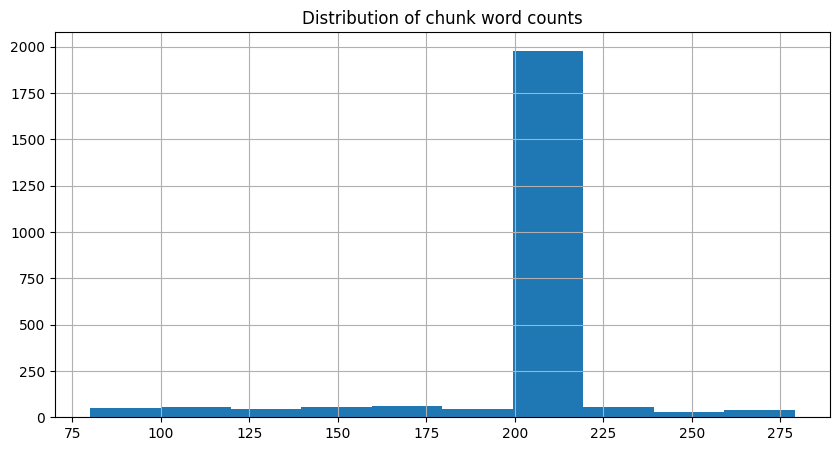

In [ ]:
df_chunks['word_count'].hist(figsize=(10,5))
plt.title("Distribution of chunk word counts")
plt.show()
# So most of the chunks have around 200 to 220 word count which is suitable for word embedding. Small leftover chunks are rare, so additional merging is not needed.

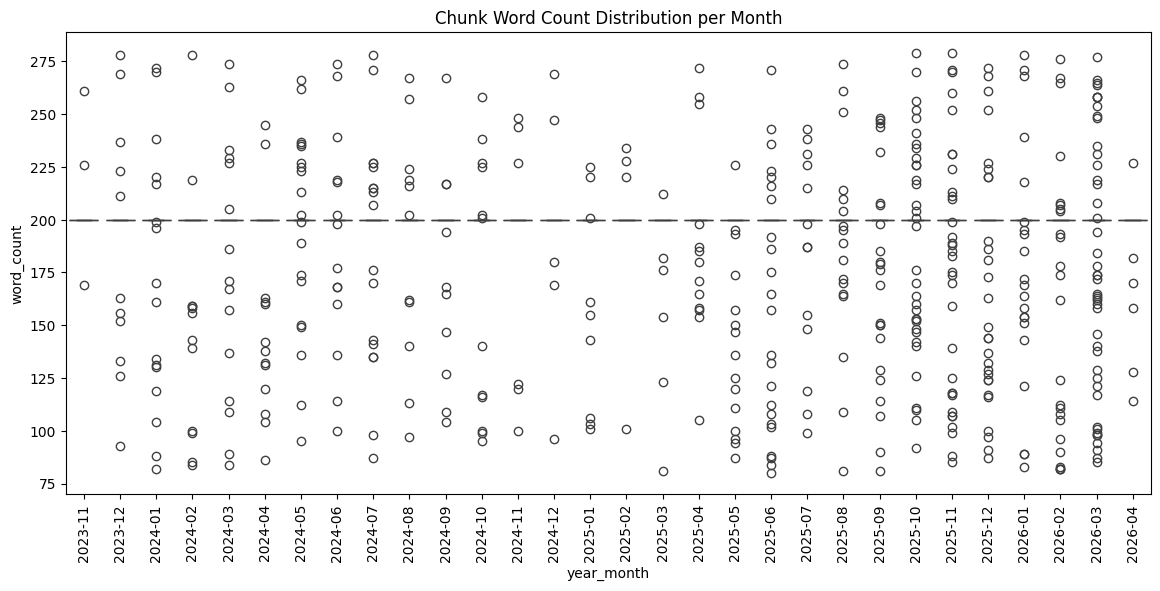

In [ ]:
plt.figure(figsize=(14,6))
df_chunks = df_chunks.sort_values('year_month')
sns.boxplot(data=df_chunks, x='year_month', y='word_count')
plt.xticks(rotation=90)
plt.title("Chunk Word Count Distribution per Month")
plt.show()

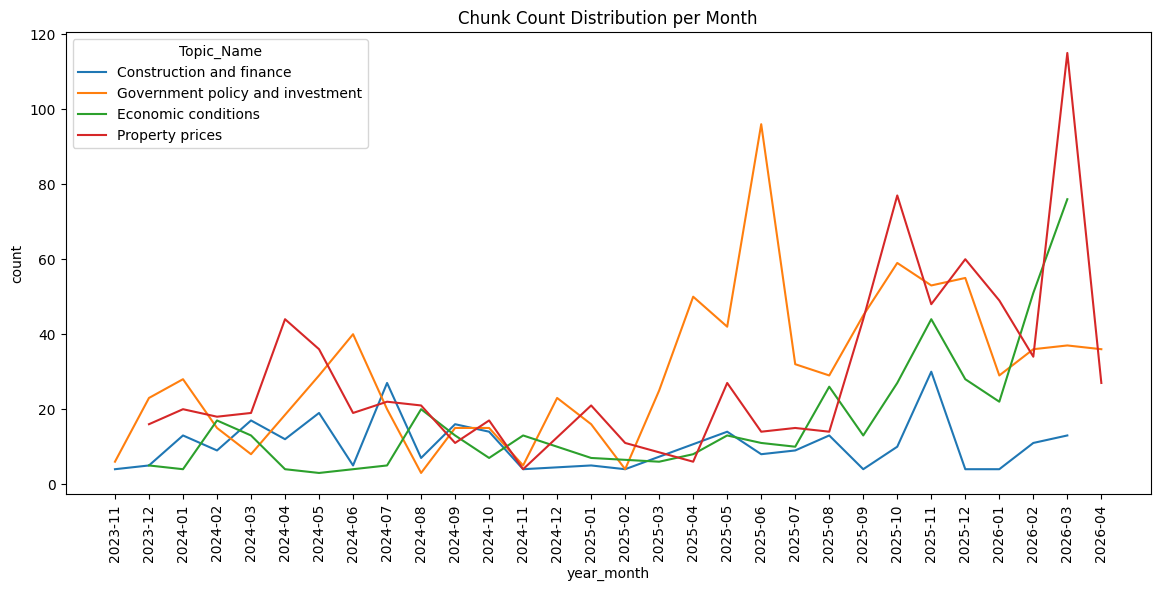

In [ ]:
# number of chunks per month
plt.figure(figsize=(14,6))
df_chunks = df_chunks.sort_values('year_month')
df_chunks_by_group = df_chunks.groupby(['year_month','Topic_Name']).size().reset_index(name='count')
sns.lineplot(data=df_chunks_by_group, x='year_month', y= 'count', hue = "Topic_Name")
plt.xticks(rotation=90)
plt.title("Chunk Count Distribution per Month")
plt.show() #

Preprocessing:

We don't need heavy preprocessing as we did in topic modelling here because the embeddings modles like all-MiniLM-L6-v2 can already handle normal text punctuation,  

In [ ]:
# Define light preprocess function for MLP
def light_preprocess(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Replace multiple whitespaces
    text = re.sub(r'\s+', ' ', text)
    # Strip leading/trailing spaces
    text = text.strip()
    # Lowercase
    text = text.lower()
    return text

df_chunks['lightpreprocessed_chunk'] = df_chunks['chunk'].apply(light_preprocess)

In [ ]:
df_chunks.head()

,title,article_id,link,author,website,date,year_month,Topic_Name,combined_text,chunk,word_count,lightpreprocessed_chunk
0,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,Imported Builders: The Solution to Australia's...,200,imported builders: the solution to australia's...
1,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,leave the country for good. But my tip is this...,200,leave the country for good. but my tip is this...
2,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,solution. It wants the Federal government to o...,200,solution. it wants the federal government to o...
3,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,down.” Melbourne and Brisbane to lead property...,261,down.” melbourne and brisbane to lead property...
4,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,Why Migration is Fuelling Greater House Price ...,200,why migration is fuelling greater house price ...


In [ ]:
# Train/test split
article_ids = df_chunks['article_id'].unique()
train_ids, test_ids = train_test_split(article_ids, test_size=0.2, random_state=42)

train_df = df_chunks[df_chunks['article_id'].isin(train_ids)]
test_df  = df_chunks[df_chunks['article_id'].isin(test_ids)]


In [ ]:
print(f"Size of train datasetr: {train_df.shape}")
print(f"Size of test dataset: {test_df.shape}")

Size of train datasetr: (1892, 12)
Size of test dataset: (518, 12)


In [ ]:
## Generate Embeddings
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train = embed_model.encode(train_df['lightpreprocessed_chunk'].tolist(), batch_size=32)
X_test = embed_model.encode(test_df['lightpreprocessed_chunk'].tolist(), batch_size=32)





/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
train_df['embedding'] = list(X_train) # add back to original df
test_df['embedding'] = list(X_test)

train_df.head(2)

/tmp/ipykernel_32332/2596623202.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['embedding'] = list(X_train) # add back to original df
/tmp/ipykernel_32332/2596623202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['embedding'] = list(X_test)


,title,article_id,link,author,website,date,year_month,Topic_Name,combined_text,chunk,word_count,lightpreprocessed_chunk,embedding
4,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,Why Migration is Fuelling Greater House Price ...,200,why migration is fuelling greater house price ...,"[0.08140472, -0.092199996, 0.010764497, 0.0359..."
5,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,minus how many left) accounts for the lion’s s...,200,minus how many left) accounts for the lion’s s...,"[0.03985664, -0.084788784, 0.027876047, 0.0401..."


In [ ]:
print(f"train set shape: {X_train.shape}")
print(f"test set shape: {X_test.shape}")
len(X_test[0])

train set shape: (1892, 384)
test set shape: (518, 384)


384

### Use embeddings for classification


In [ ]:
X_train_matrix = np.vstack(train_df['embedding'].values)  # feeding into a model like MLPClassifier, need to stack them back into a 2D array
X_test_matrix = np.vstack(test_df['embedding'].values) # feeding into a model like MLPClassifier, need to stack them back into a 2D array

# scale the embeddings
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_matrix)
X_test_scaled = scaler.transform(X_test_matrix)

y_train = train_df['Topic_Name']
y_test = test_df['Topic_Name']

#Label encode Y
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


In [ ]:
# Build an MLP Classifier
# MLPClassifier automatically sets the input layer size to match the number of features in X (ie. 384). Therefore, no need to define input layer.
param_grid = {
    "hidden_layer_sizes": [(128, 64, 32), (256, 128,64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [200, 300]
}

mlp = MLPClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='accuracy',  # or 'f1_macro' for imbalanced classes
    cv=3,                # 3-fold cross-validation
    n_jobs=-1,           # use all cores
    verbose=2
)

grid_search.fit(X_train_scaled, y_train_encoded)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=3, estimator=MLPClassifier(random_state=42), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(128, 64, 32),
                                                (256, 128, 64, 32)],
                         'learning_rate_init': [0.001, 0.01],
                         'max_iter': [200, 300], 'solver': ['adam', 'sgd']},
             scoring='accuracy', verbose=2)

In [ ]:
print("Best Accuracy:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

best_mlp = grid_search.best_estimator_


Best Accuracy: 0.8086735592282345
Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64, 32), 'learning_rate_init': 0.001, 'max_iter': 200, 'solver': 'sgd'}


In [ ]:
# save the trained model
joblib.dump(best_mlp, "/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/best_mlp.joblib")


['/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/best_mlp.joblib']

In [ ]:
# load model
best_mlp = joblib.load("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/best_mlp.joblib")

In [ ]:
#Predict for test data
y_pred = best_mlp.predict(X_test_scaled)

# get the article level prediction
test_df['pred_topic'] = y_pred
# Group by article_id
article_preds = test_df.groupby('article_id')['pred_topic'].agg(lambda x: x.value_counts().idxmax()) # Majority Voting

# True labels (assuming same label for all chunks in article)
test_df['label_encoded'] = y_test_encoded
article_true = test_df.groupby('article_id')['label_encoded'].first()

print("Accuracy:", accuracy_score(article_true, article_preds))
print(classification_report(article_true, article_preds,target_names=le.classes_))

# Even if the chunkwise accuracy is 80%, article wise accuracy is 91%. Construction and finance shows lower performance.

Accuracy: 0.9175257731958762
                                  precision    recall  f1-score   support

        Construction and finance       0.75      0.67      0.71         9
             Economic conditions       1.00      0.94      0.97        16
Government policy and investment       0.90      0.97      0.94        38
                 Property prices       0.94      0.91      0.93        34

                        accuracy                           0.92        97
                       macro avg       0.90      0.87      0.88        97
                    weighted avg       0.92      0.92      0.92        97



/tmp/ipykernel_32332/519489830.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred_topic'] = y_pred
/tmp/ipykernel_32332/519489830.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['label_encoded'] = y_test_encoded


## Sentiment analysis
Sentiment analysis will be done using distilbert-base-uncased-finetuned-sst-2-english (BERT) pretrained model. Therefore, light processing was needed and the same light preprocessed chunks were used. The model is already finetuned therefore, hyperparameter tuning was not required.  

In [ ]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.eval()


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    score = probs[0][1].item()  # probability of positive class

    if score > 0.6:
        label = "positive"
    elif score < 0.4:
        label = "negative"
    else:
        label = "neutral"   # custom neutral zone

    return label, score

In [ ]:
# Apply to preprocessed chunks
df_chunks[['sentiment', 'sentiment_score']] = df_chunks['lightpreprocessed_chunk'].apply(
    lambda x: pd.Series(predict_sentiment(x))
)

In [ ]:
df_chunks.to_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/df_chunks_sentiment.csv", index=False)

In [ ]:
df_chunks_sentiment = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MA5851_Data Science Master Class 1/Assessment3/data/df_chunks_sentiment.csv")
df_chunks_sentiment.head()

,title,article_id,link,author,website,date,year_month,Topic_Name,combined_text,chunk,word_count,lightpreprocessed_chunk,sentiment,sentiment_score
0,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,Imported Builders: The Solution to Australia's...,200,imported builders: the solution to australia's...,negative,0.359424
1,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,leave the country for good. But my tip is this...,200,leave the country for good. but my tip is this...,negative,0.001991
2,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,solution. It wants the Federal government to o...,200,solution. it wants the federal government to o...,negative,0.001139
3,Imported Builders: The Solution to Australia's...,0,https://australianpropertyupdate.com.au/apu/bu...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-29,2023-11,Construction and finance,Imported Builders: The Solution to Australia's...,down.” Melbourne and Brisbane to lead property...,261,down.” melbourne and brisbane to lead property...,negative,0.031896
4,Why Migration is Fuelling Greater House Price ...,1,https://australianpropertyupdate.com.au/apu/wh...,Scott Kuru,Australian_Property_Update/housing-trends,2023-11-28,2023-11,Government policy and investment,Why Migration is Fuelling Greater House Price ...,Why Migration is Fuelling Greater House Price ...,200,why migration is fuelling greater house price ...,positive,0.686426


In [ ]:
df_chunks_sentiment['sentiment'].value_counts()

,count
sentiment,
negative,1432
positive,893
neutral,85


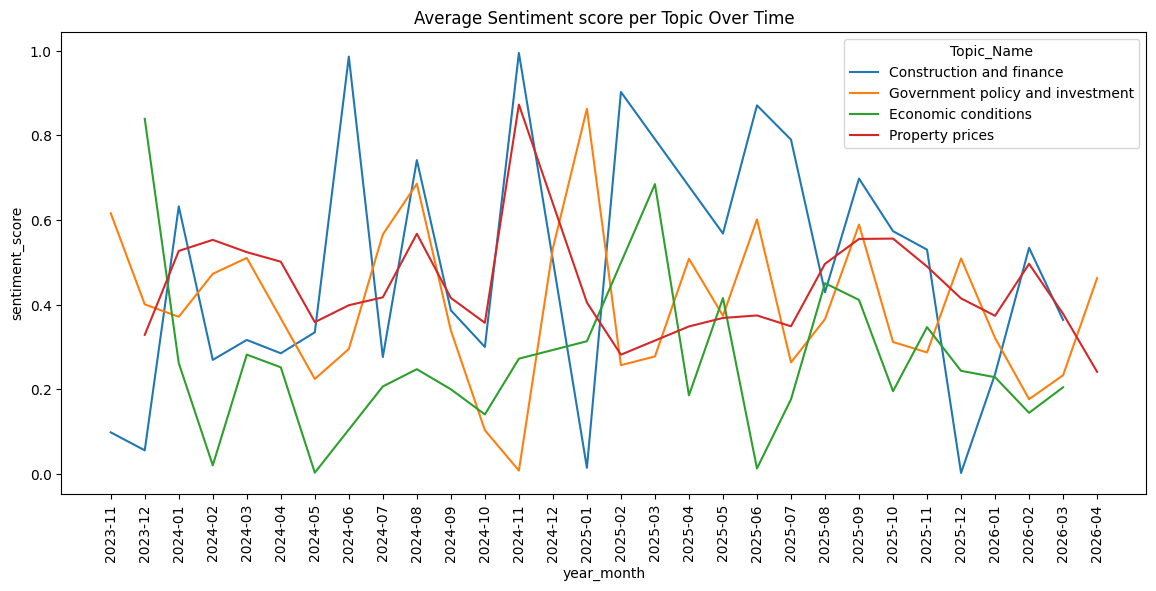

In [ ]:
plt.figure(figsize=(14,6))
df_chunks_by_group = df_chunks_sentiment.groupby(['year_month','Topic_Name'])['sentiment_score'].mean().reset_index()
sns.lineplot(data=df_chunks_by_group, x='year_month', y= 'sentiment_score', hue = "Topic_Name")
plt.xticks(rotation=90)
plt.title("Average Sentiment score per Topic Over Time")
plt.show() #